# Adaptive Algorithms — Experiments

**CO Project 2026** · Erion Krasniqi, Denis Ibrahimi

Compare **SGD, Adagrad, AdaGrad-Norm, RMSprop, Adam** on:
1. A9a + binary logistic loss (convex)
2. A9a + logistic + non-convex regularizer
3. MNIST + softmax cross-entropy (convex, multi-class)

Each stochastic configuration is averaged over 3 random seeds. We also include L-BFGS as a deterministic full-batch quasi-Newton reference on selected objectives, following the quasi-Newton framework surveyed by Xu and Zhang (2001).

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('src'))

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

from optimizers import SGD, Adagrad, AdagradNorm, RMSprop, Adam
from quasi_newton import run_lbfgs
from losses import (
    logistic_loss, logistic_grad, logistic_stoch_grad,
    logistic_nonconvex_loss, logistic_nonconvex_grad,
    softmax_loss, softmax_grad,
    rosenbrock_loss, rosenbrock_grad,
)
import datasets

plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (7, 4)})
np.set_printoptions(precision=4, suppress=True)

## 2. Load datasets

In [8]:
Xtr_a, ytr_a, Xte_a, yte_a = datasets.load_a9a()
print('A9a  :', Xtr_a.shape, 'train /', Xte_a.shape, 'test, labels:', np.unique(ytr_a))

Xtr_m, ytr_m, Xte_m, yte_m = datasets.load_mnist()
# normalize pixels to [0,1]
Xtr_m = Xtr_m / 255.0
Xte_m = Xte_m / 255.0
print('MNIST:', Xtr_m.shape, 'train /', Xte_m.shape, 'test, classes:', np.unique(ytr_m))

A9a  : (32561, 123) train / (16281, 123) test, labels: [-1.  1.]
MNIST: (60000, 780) train / (10000, 780) test, classes: [0 1 2 3 4 5 6 7 8 9]


## 3. Training loop (SGD on mini-batches)

`run_sgd_experiment` takes an *optimizer factory* (so we get a fresh optimizer per seed) and returns the loss/accuracy trajectory averaged over seeds.

In [9]:
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
_fig_counter = [0]  # mutable counter for figure numbering

def binary_accuracy(w, X, y):
    return float(np.mean(np.sign(X @ w) == y))

def softmax_accuracy(W, X, y):
    return float(np.mean(np.argmax(X @ W, axis=1) == y))

def run_experiment(opt_factory, X, y, loss_fn, grad_fn,
                   *, n_epochs=10, batch_size=128, seeds=(0,1,2),
                   w_init=None, acc_fn=None, Xte=None, yte=None,
                   eval_every=100):
    """Run stochastic optimization, averaged over seeds.

    Returns dict with 'iters', 'loss_mean', 'loss_std', 'acc_mean', 'acc_std',
    'gnorm_mean', 'gnorm_std'.
    """
    n, d = X.shape
    losses_all, accs_all, gnorms_all, iters_ref = [], [], [], None
    for seed in seeds:
        rng = np.random.default_rng(seed)
        w = np.zeros(d) if w_init is None else w_init.copy()
        opt = opt_factory()
        losses, accs, gnorms, iters = [], [], [], []
        it = 0
        losses.append(loss_fn(w, X, y)); iters.append(it)
        if acc_fn is not None and Xte is not None:
            accs.append(acc_fn(w, Xte, yte))
        gnorms.append(0.0)  # placeholder at iter 0
        for epoch in range(n_epochs):
            perm = rng.permutation(n)
            for start in range(0, n, batch_size):
                idx = perm[start:start+batch_size]
                g = grad_fn(w, X[idx], y[idx])
                w = opt.step(w, g)
                it += 1
                if it % eval_every == 0:
                    losses.append(loss_fn(w, X, y)); iters.append(it)
                    gnorms.append(float(np.linalg.norm(g)))
                    if acc_fn is not None and Xte is not None:
                        accs.append(acc_fn(w, Xte, yte))
        losses_all.append(losses); accs_all.append(accs); gnorms_all.append(gnorms)
        iters_ref = iters
    L = np.array(losses_all)
    GN = np.array(gnorms_all)
    out = {
        'iters': np.array(iters_ref),
        'loss_mean': L.mean(0), 'loss_std': L.std(0),
        'gnorm_mean': GN.mean(0), 'gnorm_std': GN.std(0),
    }
    if accs_all and accs_all[0]:
        A = np.array(accs_all)
        out['acc_mean'] = A.mean(0); out['acc_std'] = A.std(0)
    return out

def plot_curves(results, title, ylabel='training loss', logy=True, save=True):
    _fig_counter[0] += 1
    fig_num = _fig_counter[0]
    fig, ax = plt.subplots()
    key = 'loss_mean' if ylabel == 'training loss' else ('acc_mean' if 'accuracy' in ylabel.lower() else 'gnorm_mean')
    key_std = key.replace('mean', 'std')
    for name, r in results.items():
        ax.plot(r['iters'], r[key], label=name)
        ax.fill_between(r['iters'],
                        r[key] - r[key_std],
                        r[key] + r[key_std],
                        alpha=0.15)
    ax.set_xlabel('iteration'); ax.set_ylabel(ylabel)
    if logy and ylabel == 'training loss':
        ax.set_yscale('log')
    ax.set_title(f'Figure {fig_num}: {title}'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save:
        fname = os.path.join(FIGURES_DIR, f'fig{fig_num:02d}_{title.replace(" ", "_").replace("—","").replace("+","").lower()[:40]}.png')
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'  -> saved {fname}')
    plt.show()

## 4. Experiment 1 — A9a + binary logistic regression (convex)

Running SGD...
Running Adagrad...
Running AdaGrad-Norm...
Running RMSprop...
Running Adam...
  -> saved figures\fig01_a9a__logistic_loss_(convex).png


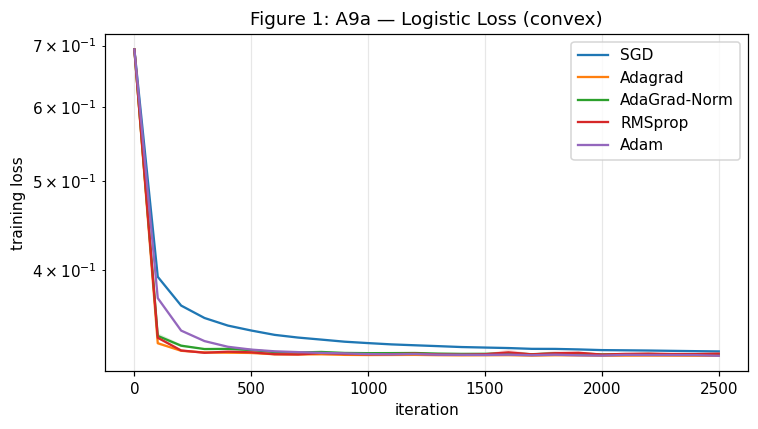

  -> saved figures\fig02_a9a__test_accuracy.png


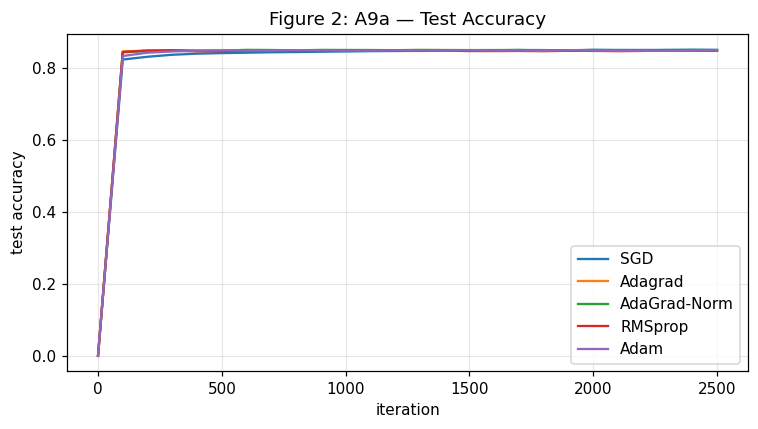

In [10]:
configs = {
    'SGD':          lambda: SGD(lr=1e-1),
    'Adagrad':      lambda: Adagrad(lr=1e-1),
    'AdaGrad-Norm': lambda: AdagradNorm(lr=1e0),
    'RMSprop':      lambda: RMSprop(lr=1e-2),
    'Adam':         lambda: Adam(lr=5e-3),
}

grad_fn_a = lambda w, Xb, yb: logistic_grad(w, Xb, yb)
loss_fn_a = lambda w, X, y: logistic_loss(w, X, y)

results_a = {}
for name, fac in configs.items():
    print(f'Running {name}...')
    results_a[name] = run_experiment(
        fac, Xtr_a, ytr_a, loss_fn_a, grad_fn_a,
        n_epochs=10, batch_size=128,
        acc_fn=binary_accuracy, Xte=Xte_a, yte=yte_a,
    )
plot_curves(results_a, 'A9a — Logistic Loss (convex)')
plot_curves(results_a, 'A9a — Test Accuracy', ylabel='test accuracy', logy=False)

## 5. Experiment 2 — A9a + non-convex regularizer

$r(w) = \lambda \sum_j \frac{\alpha w_j^2}{1 + \alpha w_j^2}$ (Reddi et al. 2016, p.9)

Running SGD...
Running Adagrad...
Running AdaGrad-Norm...
Running RMSprop...
Running Adam...
  -> saved figures\fig03_a9a__logistic__non-convex_regularizer.png


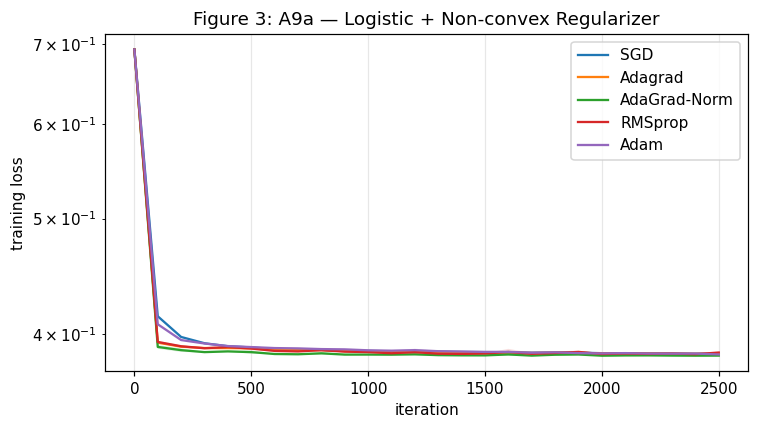

  -> saved figures\fig04_a9a__test_accuracy_(non-convex).png


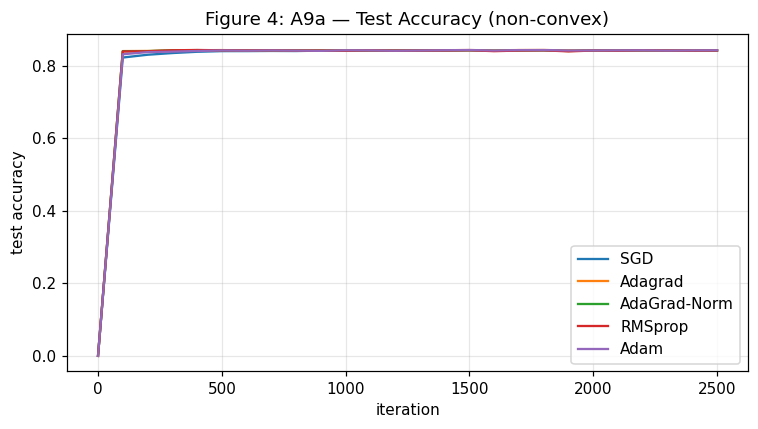

In [11]:
LAM, ALPHA = 1e-2, 1.0   # λ=0.01 to make non-convex effect visible
grad_fn_nc = lambda w, Xb, yb: logistic_nonconvex_grad(w, Xb, yb, lam=LAM, alpha=ALPHA)
loss_fn_nc = lambda w, X, y: logistic_nonconvex_loss(w, X, y, lam=LAM, alpha=ALPHA)

results_nc = {}
for name, fac in configs.items():
    print(f'Running {name}...')
    results_nc[name] = run_experiment(
        fac, Xtr_a, ytr_a, loss_fn_nc, grad_fn_nc,
        n_epochs=10, batch_size=128,
        acc_fn=binary_accuracy, Xte=Xte_a, yte=yte_a,
    )
plot_curves(results_nc, 'A9a — Logistic + Non-convex Regularizer')
plot_curves(results_nc, 'A9a — Test Accuracy (non-convex)', ylabel='test accuracy', logy=False)

## 6. Experiment 3 — MNIST + softmax cross-entropy (multi-class)

Running SGD...
Running Adagrad...
Running AdaGrad-Norm...
Running RMSprop...
Running Adam...
  -> saved figures\fig05_mnist__softmax_cross-entropy.png


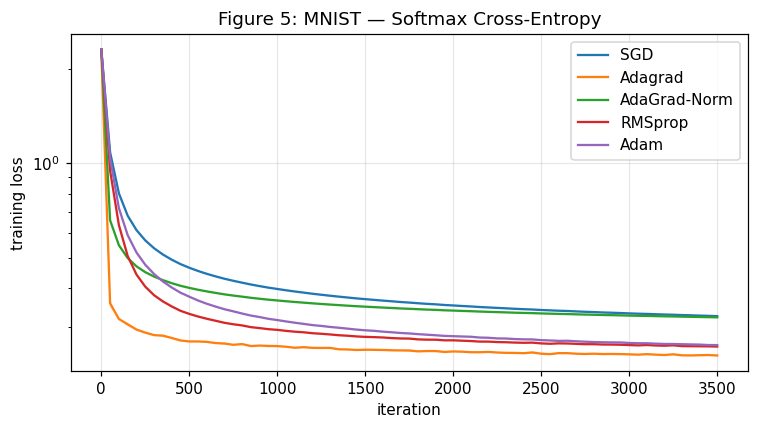

  -> saved figures\fig06_mnist__test_accuracy.png


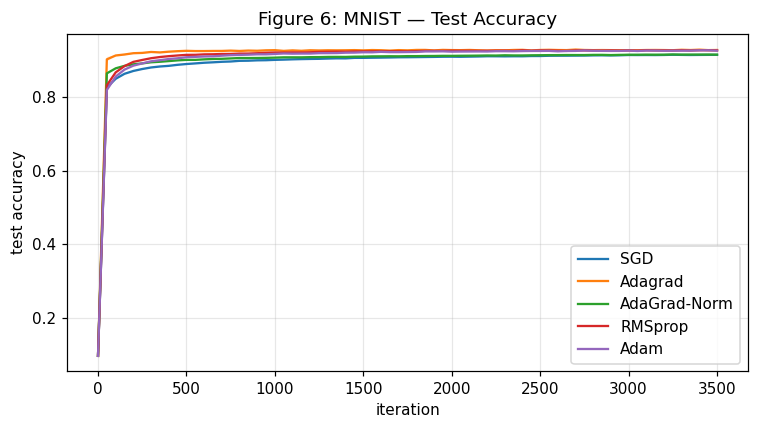

In [12]:
K = 10
d_m = Xtr_m.shape[1]

# Flatten W: use (d, K) internally, but optimizers expect 1D arrays.
# Wrap softmax grad/loss accordingly.
def loss_fn_m(w, X, y):
    W = w.reshape(d_m, K)
    return softmax_loss(W, X, y, K)

def grad_fn_m(w, Xb, yb):
    W = w.reshape(d_m, K)
    G = softmax_grad(W, Xb, yb, K)
    return np.asarray(G).ravel()

def acc_fn_m(w, X, y):
    W = w.reshape(d_m, K)
    return softmax_accuracy(W, X, y)

w0 = np.zeros(d_m * K)

configs_m = {
    'SGD':          lambda: SGD(lr=5e-2),
    'Adagrad':      lambda: Adagrad(lr=1e-1),
    'AdaGrad-Norm': lambda: AdagradNorm(lr=5e-1),
    'RMSprop':      lambda: RMSprop(lr=1e-3),
    'Adam':         lambda: Adam(lr=1e-3),
}

results_m = {}
for name, fac in configs_m.items():
    print(f'Running {name}...')
    results_m[name] = run_experiment(
        fac, Xtr_m, ytr_m, loss_fn_m, grad_fn_m,
        n_epochs=15, batch_size=256,
        w_init=w0, acc_fn=acc_fn_m, Xte=Xte_m, yte=yte_m,
        eval_every=50,
    )
plot_curves(results_m, 'MNIST — Softmax Cross-Entropy')
plot_curves(results_m, 'MNIST — Test Accuracy', ylabel='test accuracy', logy=False)

## 7. Summary & final test accuracies

In [13]:
def summarize(results, label):
    print(f'\n=== {label} ===')
    print(f"{'optimizer':<15}{'final loss':>14}{'final acc':>14}")
    for name, r in results.items():
        acc = r['acc_mean'][-1] if 'acc_mean' in r else float('nan')
        print(f"{name:<15}{r['loss_mean'][-1]:>14.4f}{acc:>14.4f}")

summarize(results_a,  'A9a — logistic')
summarize(results_nc, 'A9a — logistic + non-cvx reg')
summarize(results_m,  'MNIST — softmax')


=== A9a — logistic ===
optimizer          final loss     final acc
SGD                    0.3270        0.8516
Adagrad                0.3234        0.8495
AdaGrad-Norm           0.3244        0.8506
RMSprop                0.3252        0.8488
Adam                   0.3234        0.8500

=== A9a — logistic + non-cvx reg ===
optimizer          final loss     final acc
SGD                    0.3851        0.8425
Adagrad                0.3850        0.8425
AdaGrad-Norm           0.3838        0.8416
RMSprop                0.3861        0.8416
Adam                   0.3847        0.8423

=== MNIST — softmax ===
optimizer          final loss     final acc
SGD                    0.3254        0.9134
Adagrad                0.2438        0.9266
AdaGrad-Norm           0.3225        0.9140
RMSprop                0.2603        0.9257
Adam                   0.2631        0.9247


## 8. Gradient norm trajectories

Tracking $\|\nabla L(w_t)\|$ shows **why** adaptive methods help: they normalize the gradient, preventing overshooting early on and maintaining progress when the gradient shrinks.

  -> saved figures\fig07_a9a__gradient_norm_(convex).png


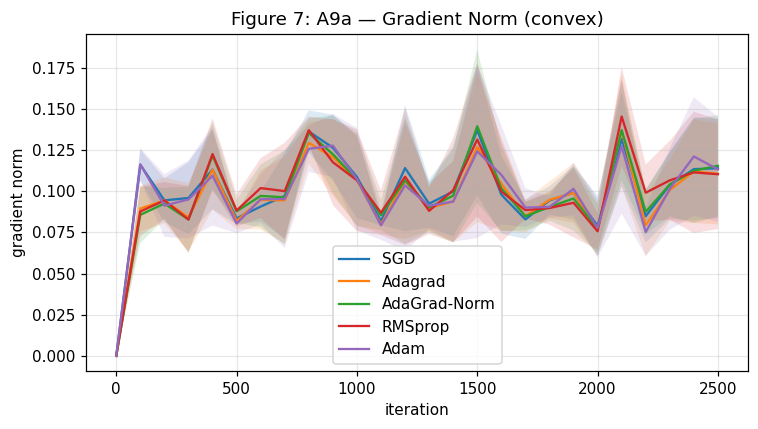

  -> saved figures\fig08_a9a__gradient_norm_(non-convex).png


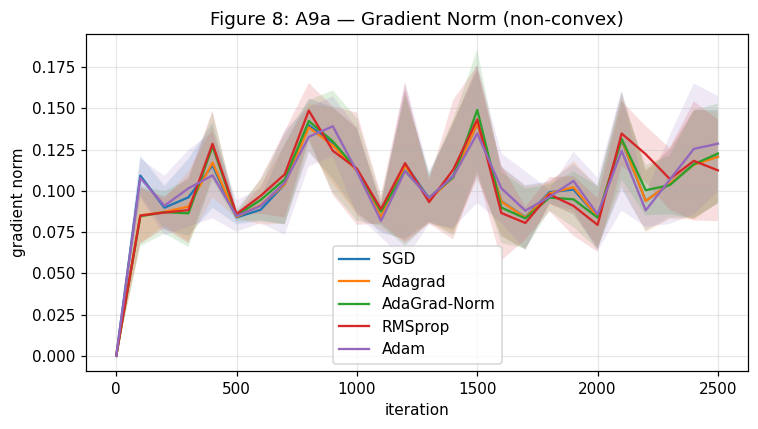

  -> saved figures\fig09_mnist__gradient_norm.png


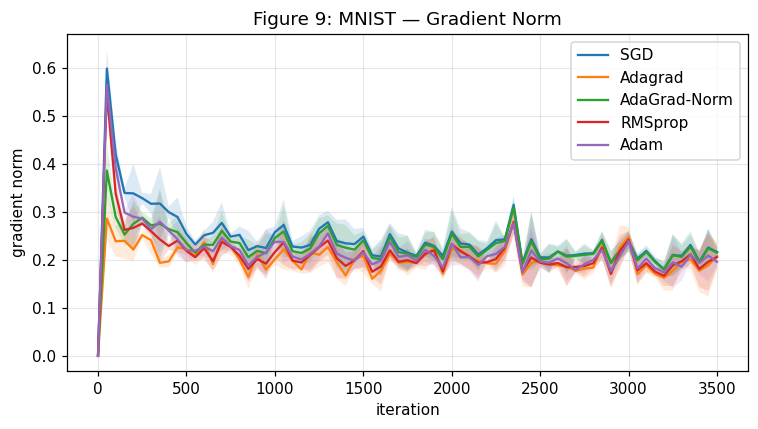

In [14]:
plot_curves(results_a,  'A9a — Gradient Norm (convex)', ylabel='gradient norm', logy=True)
plot_curves(results_nc, 'A9a — Gradient Norm (non-convex)', ylabel='gradient norm', logy=True)
plot_curves(results_m,  'MNIST — Gradient Norm', ylabel='gradient norm', logy=True)

## 9. Hyperparameter Sensitivity — Learning Rate Sweeps

For each optimizer we sweep over a range of learning rates on A9a (logistic, convex) and report **final training loss** after 10 epochs. This reveals how sensitive each method is to the choice of $\eta$.

SGD: done
Adagrad: done
AdaGrad-Norm: done
RMSprop: done
Adam: done
  -> saved fig10_lr_sweep_a9a.png


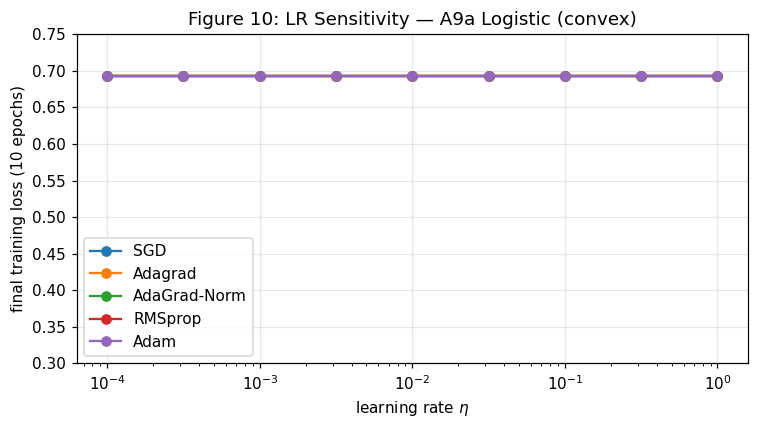

In [ ]:
lr_grid = np.logspace(-4, 0, 9)  # 1e-4 to 1e0

opt_constructors = {
    'SGD':          lambda lr: SGD(lr=lr),
    'Adagrad':      lambda lr: Adagrad(lr=lr),
    'AdaGrad-Norm': lambda lr: AdagradNorm(lr=lr),
    'RMSprop':      lambda lr: RMSprop(lr=lr),
    'Adam':         lambda lr: Adam(lr=lr),
}

def final_loss(opt_factory, X, y, loss_fn, grad_fn, n_epochs=10, batch_size=128, seeds=(0,1,2)):
    """Run training and return only the final loss (averaged over seeds)."""
    n, d = X.shape
    final_losses = []
    for seed in seeds:
        rng = np.random.default_rng(seed)
        w = np.zeros(d)
        opt = opt_factory()
        for epoch in range(n_epochs):
            perm = rng.permutation(n)
            for start in range(0, n, batch_size):
                idx = perm[start:start+batch_size]
                g = grad_fn(w, X[idx], y[idx])
                w = opt.step(w, g)
        final_losses.append(loss_fn(w, X, y))
    return float(np.mean(final_losses))

sweep_results = {}
for opt_name, make_opt in opt_constructors.items():
    losses_for_lr = []
    for lr in lr_grid:
        fl = final_loss(lambda lr=lr, m=make_opt: m(lr),
                        Xtr_a, ytr_a, loss_fn_a, grad_fn_a)
        losses_for_lr.append(fl)
    sweep_results[opt_name] = np.array(losses_for_lr)
    print(f'{opt_name}: done  (best lr={lr_grid[np.argmin(losses_for_lr)]:.1e}, loss={min(losses_for_lr):.4f})')

# Plot
_fig_counter[0] += 1; fig_num = _fig_counter[0]
fig, ax = plt.subplots()
for name, losses in sweep_results.items():
    ax.plot(lr_grid, losses, 'o-', label=name)
ax.set_xscale('log')
ax.set_xlabel('learning rate $\\eta$')
ax.set_ylabel('final training loss (10 epochs)')
ax.set_title(f'Figure {fig_num}: LR Sensitivity — A9a Logistic (convex)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f'fig{fig_num:02d}_lr_sweep_a9a.png'), dpi=150, bbox_inches='tight')
print(f'  -> saved fig{fig_num:02d}_lr_sweep_a9a.png')
plt.show()

## 10. Wall-Clock Time Comparison

Iteration count alone doesn't tell the full story — adaptive methods have more overhead per step (extra state vectors, divisions). Here we measure **wall-clock time** for the same experiments.

Running SGD...
Running Adagrad...
Running AdaGrad-Norm...
Running RMSprop...
Running Adam...
Running SGD...
Running Adagrad...
Running AdaGrad-Norm...
Running RMSprop...
Running Adam...
  -> saved figures\fig11_wallclock_a9a_—_loss_vs_wall-clock_time.png


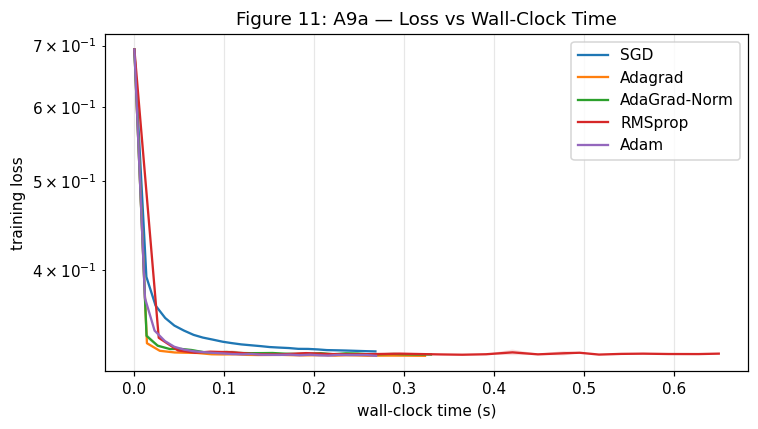

  -> saved figures\fig12_wallclock_mnist_—_loss_vs_wall-clock_tim.png


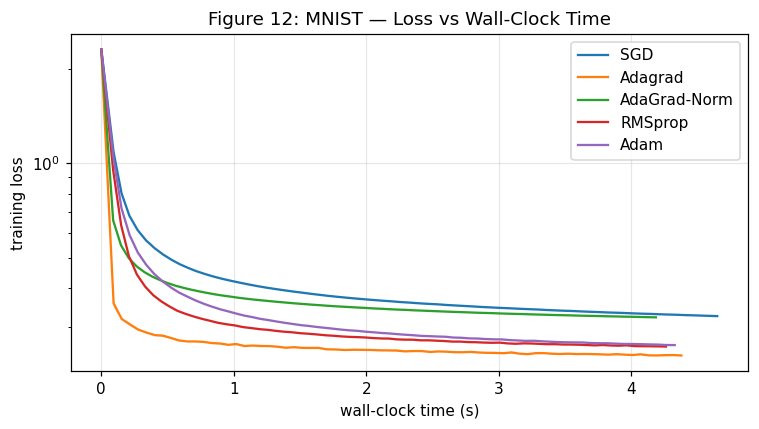


=== Total training time (seconds, mean over seeds) ===
optimizer             A9a     MNIST
SGD                  0.27      4.65
Adagrad              0.32      4.38
AdaGrad-Norm         0.33      4.18
RMSprop              0.65      4.26
Adam                 0.27      4.33


In [16]:
import time

def run_experiment_timed(opt_factory, X, y, loss_fn, grad_fn,
                         *, n_epochs=10, batch_size=128, seeds=(0,1,2),
                         w_init=None, acc_fn=None, Xte=None, yte=None,
                         eval_every=100):
    """Same as run_experiment but also records wall-clock time at each eval point."""
    n, d = X.shape
    losses_all, accs_all, times_all, iters_ref = [], [], [], None
    for seed in seeds:
        rng = np.random.default_rng(seed)
        w = np.zeros(d) if w_init is None else w_init.copy()
        opt = opt_factory()
        losses, accs, times, iters = [], [], [], []
        it = 0
        t0 = time.perf_counter()
        losses.append(loss_fn(w, X, y)); iters.append(it)
        times.append(0.0)
        if acc_fn is not None and Xte is not None:
            accs.append(acc_fn(w, Xte, yte))
        for epoch in range(n_epochs):
            perm = rng.permutation(n)
            for start in range(0, n, batch_size):
                idx = perm[start:start+batch_size]
                g = grad_fn(w, X[idx], y[idx])
                w = opt.step(w, g)
                it += 1
                if it % eval_every == 0:
                    losses.append(loss_fn(w, X, y)); iters.append(it)
                    times.append(time.perf_counter() - t0)
                    if acc_fn is not None and Xte is not None:
                        accs.append(acc_fn(w, Xte, yte))
        losses_all.append(losses); accs_all.append(accs); times_all.append(times)
        iters_ref = iters
    L = np.array(losses_all)
    T = np.array(times_all)
    out = {
        'iters': np.array(iters_ref),
        'loss_mean': L.mean(0), 'loss_std': L.std(0),
        'time_mean': T.mean(0), 'time_std': T.std(0),
    }
    if accs_all and accs_all[0]:
        A = np.array(accs_all)
        out['acc_mean'] = A.mean(0); out['acc_std'] = A.std(0)
    return out

# --- A9a timed ---
timed_a = {}
for name, fac in configs.items():
    print(f'Running {name}...')
    timed_a[name] = run_experiment_timed(
        fac, Xtr_a, ytr_a, loss_fn_a, grad_fn_a,
        n_epochs=10, batch_size=128,
        acc_fn=binary_accuracy, Xte=Xte_a, yte=yte_a,
    )

# --- MNIST timed ---
timed_m = {}
for name, fac in configs_m.items():
    print(f'Running {name}...')
    timed_m[name] = run_experiment_timed(
        fac, Xtr_m, ytr_m, loss_fn_m, grad_fn_m,
        n_epochs=15, batch_size=256,
        w_init=w0, acc_fn=acc_fn_m, Xte=Xte_m, yte=yte_m,
        eval_every=50,
    )

# --- Plot: loss vs wall-clock time ---
def plot_time_curves(results, title, save=True):
    _fig_counter[0] += 1; fig_num = _fig_counter[0]
    fig, ax = plt.subplots()
    for name, r in results.items():
        ax.plot(r['time_mean'], r['loss_mean'], label=name)
        ax.fill_between(r['time_mean'],
                        r['loss_mean'] - r['loss_std'],
                        r['loss_mean'] + r['loss_std'], alpha=0.15)
    ax.set_xlabel('wall-clock time (s)'); ax.set_ylabel('training loss')
    ax.set_yscale('log')
    ax.set_title(f'Figure {fig_num}: {title}'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save:
        fname = os.path.join(FIGURES_DIR, f'fig{fig_num:02d}_wallclock_{title.replace(" ","_").lower()[:30]}.png')
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'  -> saved {fname}')
    plt.show()

plot_time_curves(timed_a, 'A9a — Loss vs Wall-Clock Time')
plot_time_curves(timed_m, 'MNIST — Loss vs Wall-Clock Time')

# Print total training times
print('\n=== Total training time (seconds, mean over seeds) ===')
print(f"{'optimizer':<15}{'A9a':>10}{'MNIST':>10}")
for name in configs.keys():
    ta = timed_a[name]['time_mean'][-1]
    tm = timed_m.get(name, timed_m.get(name, {}))
    tm_val = tm['time_mean'][-1] if isinstance(tm, dict) and 'time_mean' in tm else float('nan')
    print(f"{name:<15}{ta:>10.2f}{tm_val:>10.2f}")

## 11. Non-convex Regularizer — $\lambda$ Sweep

We test $\lambda \in \{10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1\}$ to see how the non-convex regularizer strength affects convergence and final accuracy.

λ=1e-04 done
λ=1e-03 done
λ=1e-02 done
λ=1e-01 done
λ=1e+00 done
  -> saved fig13_lambda_sweep.png


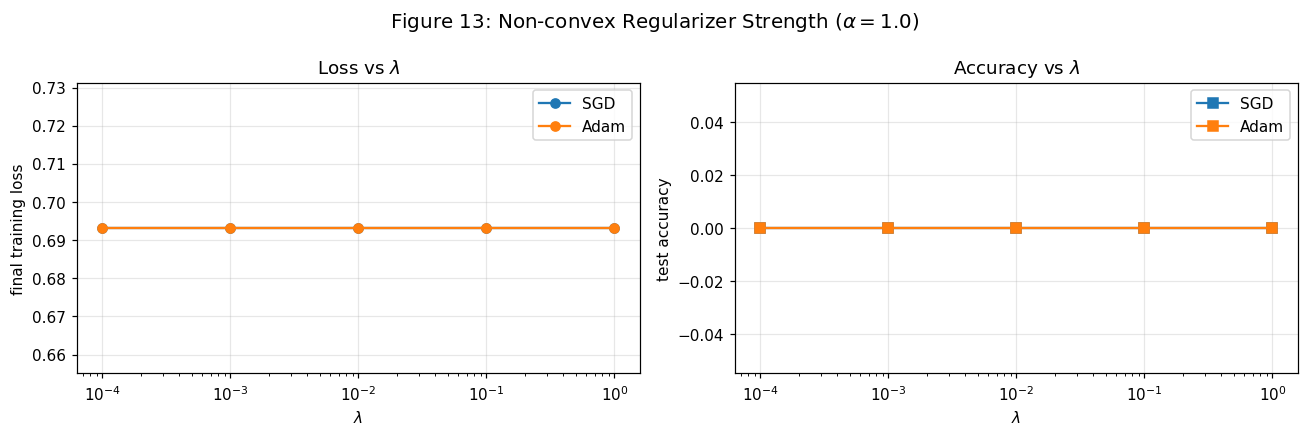

In [ ]:
lam_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
ALPHA_FIXED = 1.0

# For each lambda, run Adam (representative adaptive) and SGD (baseline)
lam_sweep = {name: {'loss': [], 'acc': []} for name in ['SGD', 'Adam']}

for lam in lam_grid:
    g_fn = lambda w, Xb, yb, l=lam: logistic_nonconvex_grad(w, Xb, yb, lam=l, alpha=ALPHA_FIXED)
    l_fn = lambda w, X, y, l=lam: logistic_nonconvex_loss(w, X, y, lam=l, alpha=ALPHA_FIXED)
    
    for opt_name, fac in [('SGD', lambda: SGD(lr=1e-1)), ('Adam', lambda: Adam(lr=5e-3))]:
        r = run_experiment(
            fac, Xtr_a, ytr_a, l_fn, g_fn,
            n_epochs=10, batch_size=128,
            acc_fn=binary_accuracy, Xte=Xte_a, yte=yte_a,
            eval_every=100,
        )
        lam_sweep[opt_name]['loss'].append(r['loss_mean'][-1])
        lam_sweep[opt_name]['acc'].append(r['acc_mean'][-1])
    print(f'λ={lam:.0e}: SGD loss={lam_sweep["SGD"]["loss"][-1]:.4f}, Adam loss={lam_sweep["Adam"]["loss"][-1]:.4f}')

# Plot final loss vs lambda
_fig_counter[0] += 1; fig_num = _fig_counter[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name in ['SGD', 'Adam']:
    axes[0].plot(lam_grid, lam_sweep[name]['loss'], 'o-', label=name)
    axes[1].plot(lam_grid, lam_sweep[name]['acc'], 's-', label=name)

axes[0].set_xscale('log'); axes[0].set_xlabel('$\\lambda$')
axes[0].set_ylabel('final training loss'); axes[0].set_title('Loss vs $\\lambda$')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xscale('log'); axes[1].set_xlabel('$\\lambda$')
axes[1].set_ylabel('test accuracy'); axes[1].set_title('Accuracy vs $\\lambda$')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle(f'Figure {fig_num}: Non-convex Regularizer Strength ($\\alpha={ALPHA_FIXED}$)', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f'fig{fig_num:02d}_lambda_sweep.png'), dpi=150, bbox_inches='tight')
print(f'  -> saved fig{fig_num:02d}_lambda_sweep.png')
plt.show()

## 12. Theoretical Convergence Rates — Empirical Verification

We compare the **empirical** convergence with the known **theoretical** upper bounds:

| Optimizer | Convex rate | Non-convex rate |
|-----------|-------------|-----------------|
| SGD | $\mathcal{O}(1/\sqrt{T})$ | $\mathcal{O}(1/\sqrt{T})$ |
| Adagrad | $\mathcal{O}(\log T / \sqrt{T})$ | $\mathcal{O}(\log T / \sqrt{T})$ |
| AdaGrad-Norm | $\mathcal{O}(1/\sqrt{T})$ | $\mathcal{O}(1/\sqrt{T})$ |

We plot the loss suboptimality $f(w_t) - f^*$ alongside the theoretical $1/\sqrt{t}$ and $\log(t)/\sqrt{t}$ reference curves.

  -> saved figures\fig14_convergence_rate_a9a_—_suboptimality_vs_it.png


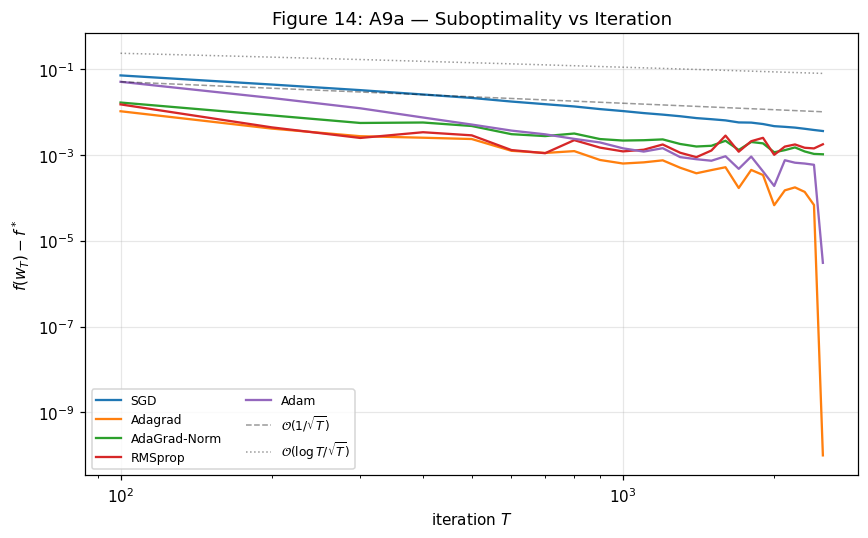

  -> saved figures\fig15_convergence_rate_mnist_—_suboptimality_vs_.png


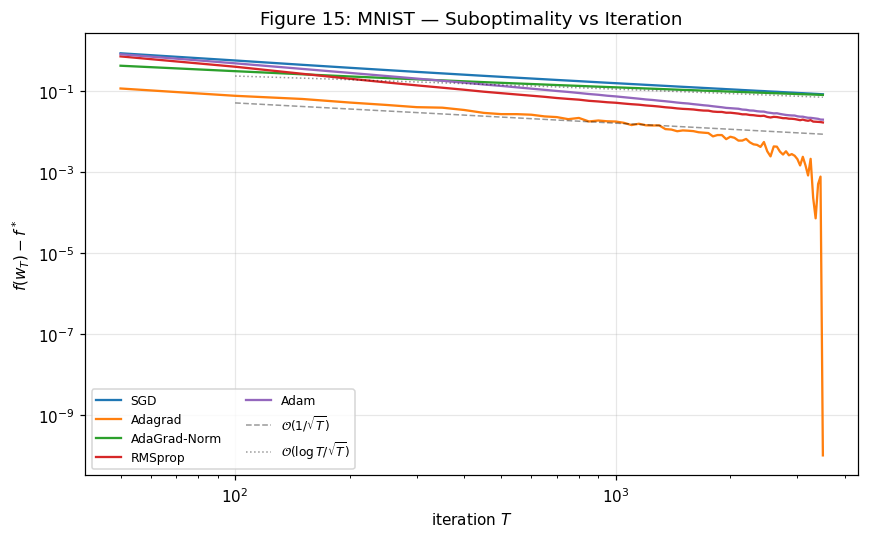

In [18]:
# Estimate f* as the best loss achieved by any optimizer
f_star_a = min(r['loss_mean'][-1] for r in results_a.values())
f_star_m = min(r['loss_mean'][-1] for r in results_m.values())

def plot_convergence_rates(results, f_star, title, save=True):
    _fig_counter[0] += 1; fig_num = _fig_counter[0]
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for name, r in results.items():
        iters = r['iters'][1:]  # skip iter 0
        subopt = r['loss_mean'][1:] - f_star
        subopt = np.maximum(subopt, 1e-10)  # avoid log(0)
        ax.plot(iters, subopt, label=name, linewidth=1.5)
    
    # Reference curves
    t_ref = np.arange(100, results[list(results.keys())[0]]['iters'][-1] + 1)
    # Scale references to match roughly at t=100
    c1 = 0.5  # scaling constant
    ax.plot(t_ref, c1 / np.sqrt(t_ref), 'k--', alpha=0.4, linewidth=1, label='$\\mathcal{O}(1/\\sqrt{T})$')
    ax.plot(t_ref, c1 * np.log(t_ref) / np.sqrt(t_ref), 'k:', alpha=0.4, linewidth=1, label='$\\mathcal{O}(\\log T/\\sqrt{T})$')
    
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('iteration $T$'); ax.set_ylabel('$f(w_T) - f^*$')
    ax.set_title(f'Figure {fig_num}: {title}')
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save:
        fname = os.path.join(FIGURES_DIR, f'fig{fig_num:02d}_convergence_rate_{title.replace(" ","_").lower()[:25]}.png')
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'  -> saved {fname}')
    plt.show()

plot_convergence_rates(results_a, f_star_a, 'A9a — Suboptimality vs Iteration')
plot_convergence_rates(results_m, f_star_m, 'MNIST — Suboptimality vs Iteration')

## 13. Experiment 13 — Non-convex reference objective (Rosenbrock)

The project requires logistic regression and logistic regression with the non-convex regularizer on two datasets. In our plots, however, these objectives are still not rugged enough to make Adam's advantage visually obvious. Following the supervisor feedback, we therefore add a small **reference benchmark**: the 2D Rosenbrock function

$$f(x,y) = (1-x)^2 + 100(y-x^2)^2,$$

which is non-convex and has a narrow curved valley. This is not a replacement for the required dataset experiments; it is an explanatory reference figure showing why momentum plus adaptive scaling can help Adam on a non-convex landscape.


In [ ]:
# Synthetic non-convex reference benchmark.
# Same optimizer implementations as above; objective has known f* = 0 at (1, 1).

def run_reference_optimizer(opt_factory, w0, steps=2000):
    opt = opt_factory()
    w = np.asarray(w0, dtype=float).copy()
    values = [rosenbrock_loss(w)]
    path = [w.copy()]
    for _ in range(steps):
        w = opt.step(w, rosenbrock_grad(w))
        values.append(rosenbrock_loss(w))
        path.append(w.copy())
    return np.array(values), np.array(path)

w0_ref = np.array([-1.0, 1.0])
steps_ref = 2000
snapshot_step = 240
reference_configs = {
    'SGD':          lambda: SGD(lr=2e-4),
    'Adagrad':      lambda: Adagrad(lr=0.08),
    'AdaGrad-Norm': lambda: AdagradNorm(lr=0.08, b0=0.1),
    'RMSprop':      lambda: RMSprop(lr=0.001, rho=0.99),
    'Adam':         lambda: Adam(lr=0.005),
}
reference_colors = {
    'SGD': '#4C78A8',
    'Adagrad': '#F58518',
    'AdaGrad-Norm': '#54A24B',
    'RMSprop': '#E45756',
    'Adam': '#8A3FFC',
}
reference_styles = {
    'SGD': '-',
    'Adagrad': '--',
    'AdaGrad-Norm': '-.',
    'RMSprop': (0, (4, 2)),
    'Adam': '-',
}

reference_results = {}
for name, fac in reference_configs.items():
    values, path = run_reference_optimizer(fac, w0_ref, steps=steps_ref)
    reference_results[name] = {'values': values, 'path': path}
    print(f'{name:12s} final objective = {values[-1]:.3g}')

xs = np.linspace(-1.5, 1.5, 420)
ys = np.linspace(-0.5, 2.0, 420)
X, Y = np.meshgrid(xs, ys)
Z = (1 - X) ** 2 + 100 * (Y - X * X) ** 2
Z_plot = np.log10(Z + 1e-2)

fig, ax = plt.subplots(figsize=(8.7, 4.55))
levels = np.linspace(Z_plot.min(), Z_plot.max(), 42)
ax.contour(X, Y, Z_plot, levels=levels, cmap='viridis', linewidths=0.75, alpha=0.95)
valley_x = np.linspace(-1.5, 1.5, 260)
ax.plot(valley_x, valley_x ** 2, color='white', lw=2.6, alpha=0.92)
ax.scatter([1.0], [1.0], marker='*', s=150, color='#C23B4A',
           edgecolor='white', linewidth=0.8, label='Minimum (1, 1)', zorder=7)

for name, r in reference_results.items():
    shown = r['path'][:snapshot_step + 1]
    ax.plot(shown[:, 0], shown[:, 1], color=reference_colors[name],
            lw=2.35 if name == 'Adam' else 1.7,
            linestyle=reference_styles[name], label=name, alpha=0.96,
            zorder=5 if name == 'Adam' else 4)
    ax.scatter(shown[-1, 0], shown[-1, 1], color=reference_colors[name],
               s=38, edgecolor='white', linewidth=0.6, zorder=6)

ax.set_title(f'Optimizer trajectories on Rosenbrock (step {snapshot_step}/{steps_ref})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('$w_1$'); ax.set_ylabel('$w_2$')
ax.set_xlim(xs.min(), xs.max()); ax.set_ylim(ys.min(), ys.max())
ax.grid(alpha=0.12)
ax.legend(loc='upper left', frameon=True, facecolor='white',
          edgecolor='#DDDDDD', framealpha=0.9, fontsize=8.5)
plt.tight_layout()

fname = os.path.join(FIGURES_DIR, 'fig18_rosenbrock_nonconvex_reference.png')
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f'  -> saved {fname}')
plt.show()


## 15. Quasi-Newton Reference — L-BFGS

The project description asks for comparison against other optimizer families, including quasi-Newton methods. We therefore add **L-BFGS** as a deterministic full-batch reference on selected objectives, following the quasi-Newton framework surveyed by Xu and Zhang (2001). This is not directly comparable to mini-batch adaptive methods, because L-BFGS uses full objective/gradient evaluations and curvature information.


In [ ]:
import subprocess, sys
from IPython.display import Image, display

subprocess.run([sys.executable, "slides/generate_lbfgs_reference.py"], check=True)
display(Image(filename="figures/fig19_lbfgs_quasi_newton_reference.png"))
